In [1]:
import os
import torch
import subprocess
import platform
import datetime
from pathlib import Path
import vision_transformer as vits

In [2]:
# Chemin vers l'image à visualiser
IMAGE_PATH = "/home/alex/internship/datasets/aqua20/data/aqua20/test/fish/00414.png"  # ex: "/path/to/image.jpg"

# Taille de resize (doit être divisible par PATCH_SIZE)
IMAGE_SIZE = 224

# Architecture et patch size de nos modèles entraînés
ARCH = "vit_small"
PATCH_SIZE = 16
CHECKPOINT_KEY = "teacher"  # 'teacher' ou 'student'

# Répertoire des outputs
OUTPUTS_DIR = "outputs/"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")



Device: cuda


In [3]:
def load_pretrained_dino():
    """Charge le DINO officiel ViT-S/16 depuis fbaipublicfiles."""
    model = vits.__dict__[ARCH](patch_size=PATCH_SIZE, num_classes=0)
    url = "https://dl.fbaipublicfiles.com/dino/dino_deitsmall16_pretrain/dino_deitsmall16_pretrain.pth"
    state_dict = torch.hub.load_state_dict_from_url(url, map_location="cpu")
    model.load_state_dict(state_dict, strict=True)
    print("  DINO pretrained loaded.")
    model.eval().to(DEVICE)
    return model

In [4]:
# RUN_TO_EVAL = "dino_aqua20_distilled"
RUN_TO_EVAL = "dino-no-repeat-aqua20-20260505_180527" 

# ── Paths (per-platform) ────────────────────────────────────────────────────
if platform.system() == "Darwin":
    REPO_DIR  = Path("/Users/alex/Developpement/Internship/dinoDD")
    DATA_ROOT = Path("/Users/alex/Developpement/Internship/datasets/aqua20/data/aqua20")
else:
    REPO_DIR  = Path("/home/alex/internship/dinoDD")
    DATA_ROOT = Path("/home/alex/internship/datasets/aqua20/data/aqua20")

if RUN_TO_EVAL is None:
    run_label = "dino_pretrained_official"
    pretrained_weights = ""
else:
    run_label = RUN_TO_EVAL
    pretrained_weights = str(REPO_DIR / "outputs" / RUN_TO_EVAL / "checkpoint.pth")


# ── Run configuration ───────────────────────────────────────────────────────
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = REPO_DIR / "outputs" / f"knn-eval-{run_label}-{timestamp}"
output_dir.mkdir(parents=True, exist_ok=True)


HP = dict(
    # Model
    arch               = "vit_small",
    patch_size         = 16,
    pretrained_weights = pretrained_weights,
    checkpoint_key     = "teacher",
    # Data
    data_path          = str(DATA_ROOT),
    num_classes        = 20,
    # k-NN
    nb_knn             = [1, 5, 10, 20],
    temperature        = 0.07,
    # Runtime
    batch_size_per_gpu = 64,
    num_workers        = 4,
    use_cuda           = torch.cuda.is_available(),
    # Feature caching — saved to output_dir for t-SNE visualisation
    dump_features      = str(output_dir),
    load_features      = None,
)

print(f"Run name : {RUN_TO_EVAL}")
print(f"Output   : {output_dir}")

Run name : dino-no-repeat-aqua20-20260505_180527
Output   : /home/alex/internship/dinoDD/outputs/knn-eval-dino-no-repeat-aqua20-20260505_180527-20260511_202500


In [5]:
# Build cmd avec torchrun + tous les HP
cmd = ["uv", "run", "torchrun", "--nproc_per_node=1", "--master_port=29500", "eval_knn.py"]
for key, value in HP.items():
    if value is None:
        continue
    flag = f"--{key}"
    if isinstance(value, bool):
        cmd += [flag, "true" if value else "false"]
    elif isinstance(value, list):
        cmd += [flag] + [str(v) for v in value]
    else:
        cmd += [flag, str(value)]
cmd += ["--dist_url", f"file:///tmp/dino_dist_{timestamp}"]

# Env conditionnel à Linux
env = os.environ.copy()
if platform.system() == "Linux":
    env["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + env.get("LD_LIBRARY_PATH", "")

In [6]:
# ── Launch training and stream output ────────────────────────────────────────
# stdout + stderr are merged and streamed line-by-line:
#   - printed to this cell (visible in notebook)
#   - written to {output_dir}/knn.log
#
# Interrupting the kernel stops the streaming loop but NOT the subprocess.
# The process keeps running and logs keep accumulating in knn.log.

log_path = output_dir / "knn.log"

process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    cwd=str(REPO_DIR),
    env=env,
)

print(f"Started PID={process.pid}  log={log_path}")
print("=" * 70)

with open(log_path, "w") as log_file:
    for line in process.stdout:
        print(line, end="", flush=True)
        log_file.write(line)
        log_file.flush()

process.wait()
print(f"\nProcess exited with code {process.returncode}")

Started PID=59471  log=/home/alex/internship/dinoDD/outputs/knn-eval-dino-no-repeat-aqua20-20260505_180527-20260511_202500/knn.log
| distributed init (rank 0): file:///tmp/dino_dist_20260511_202500
git:
  sha: 6ab3dded8381e24486393caa18c736b976d6e08e, status: clean, branch: feat/wandb-knn-eval

Using device: cuda
arch: vit_small
batch_size_per_gpu: 64
checkpoint_key: teacher
data_path: /home/alex/internship/datasets/aqua20/data/aqua20
device: cuda
dist_url: file:///tmp/dino_dist_20260511_202500
dump_features: /home/alex/internship/dinoDD/outputs/knn-eval-dino-no-repeat-aqua20-20260505_180527-20260511_202500
gpu: 0
load_features: None
local_rank: 0
nb_knn: [1, 5, 10, 20]
num_classes: 20
num_workers: 4
patch_size: 16
pretrained_weights: /home/alex/internship/dinoDD/outputs/dino-no-repeat-aqua20-20260505_180527/checkpoint.pth
rank: 0
temperature: 0.07
use_cuda: True
world_size: 1
Data loaded with 6559 train and 1612 val imgs.
Model vit_small 16x16 built.
Please use the `--pretrained_weigh

Running t-SNE on 1612 test samples …
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1612 samples in 0.000s...
[t-SNE] Computed neighbors for 1612 samples in 0.073s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1612
[t-SNE] Computed conditional probabilities for sample 1612 / 1612
[t-SNE] Mean sigma: 0.257536
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.320557
[t-SNE] KL divergence after 1000 iterations: 1.149163
Done.


/tmp/ipykernel_59368/449115272.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", num_classes)


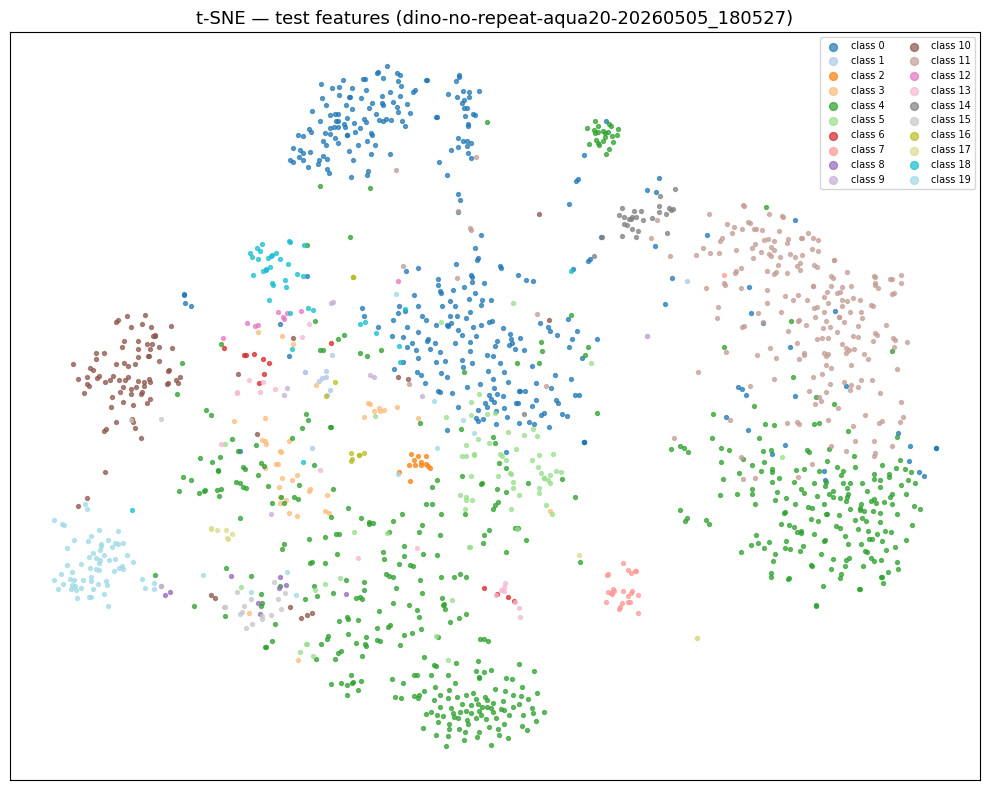

Saved to /home/alex/internship/dinoDD/outputs/knn-eval-dino-no-repeat-aqua20-20260505_180527-20260511_202500/tsne.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE

# ── Load saved features ───────────────────────────────────────────────────────
feat_dir = Path(HP["dump_features"])
test_features = torch.load(feat_dir / "testfeat.pth", map_location="cpu").numpy()
test_labels   = torch.load(feat_dir / "testlabels.pth", map_location="cpu").numpy()

# ── Run t-SNE ─────────────────────────────────────────────────────────────────
print(f"Running t-SNE on {len(test_labels)} test samples …")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, verbose=1)
emb = tsne.fit_transform(test_features)
print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
num_classes = HP["num_classes"]
colors = cm.get_cmap("tab20", num_classes)

fig, ax = plt.subplots(figsize=(10, 8))
for cls in np.unique(test_labels):
    mask = test_labels == cls
    ax.scatter(emb[mask, 0], emb[mask, 1],
               s=8, alpha=0.7, color=colors(cls), label=f"class {cls}")

ax.set_title(f"t-SNE — test features ({run_label})", fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="best", markerscale=2, fontsize=7, ncol=2)
plt.tight_layout()

tsne_path = feat_dir / "tsne.png"
plt.savefig(tsne_path, dpi=150)
plt.show()
print(f"Saved to {tsne_path}")